In [6]:
!pip install matplotlib-venn

In [8]:
!pip install -q torchmetrics[image] pytorch-fid ninja torch-fidelity

In [23]:
import os
import sys
import subprocess
import urllib.request
import warnings

# Suppress CUDA plugin compile fallback warnings and future warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*Failed to build CUDA kernels.*')
warnings.filterwarnings('ignore', category=UserWarning, module='torchmetrics')

# Force silent installation of required metric packages including torch-fidelity
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchmetrics[image]", "pytorch-fid", "ninja", "torch-fidelity"], check=True)

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torchvision.utils import save_image
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

REPO = 'stylegan2-ada-pytorch'
REPO_URL = 'https://github.com/NVlabs/stylegan2-ada-pytorch.git'

def clone_repo():
    if not os.path.exists(REPO):
        print("Cloning StyleGAN2-ADA repository...")
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    if os.path.abspath(REPO) not in sys.path:
        sys.path.append(os.path.abspath(REPO))

clone_repo()

# Force StyleGAN2-ADA to use native PyTorch fallback ops and skip compilation
import torch_utils.custom_ops
torch_utils.custom_ops.verbosity = 'none'

import legacy

MODEL_URL = 'https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl'
MODEL_PATH = 'ffhq.pkl'

def download_model():
    if not os.path.exists(MODEL_PATH):
        print("Downloading FFHQ model weights...")
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

download_model()

def generate_images(num_images=16, truncation_psi=0.7):
    print(f"Generating {num_images} synthetic images...")
    with open(MODEL_PATH, 'rb') as f:
        G = legacy.load_network_pkl(f)['G_ema'].to(device).eval()

    os.makedirs('generated_images', exist_ok=True)
    imgs = []

    with torch.no_grad():
        for i in range(num_images):
            z = torch.randn([1, G.z_dim], device=device)
            c = torch.zeros([1, G.c_dim], device=device)
            img = G(z, c, truncation_psi=truncation_psi, noise_mode='const')
            img = (img.clamp(-1, 1) + 1) * 0.5
            save_image(img, f'generated_images/fake_{i:04d}.png')
            imgs.append(img.cpu())

    return torch.cat(imgs, dim=0)

def calculate_inception_score(imgs):
    print("\nCalculating Inception Score...")
    import torch_fidelity
    # Correct parameter name to 'input1'
    metrics = torch_fidelity.calculate_metrics(
        input1='generated_images',
        isc=True,
        fid=False,
        kid=False,
        verbose=False,
        cuda=torch.cuda.is_available()
    )
    mean = metrics['inception_score_mean']
    std = metrics['inception_score_std']
    print(f"Inception Score: {mean:.4f} ± {std:.4f}")

def prepare_real_images(num_real=16):
    print(f"\nPreparing {num_real} real target images...")
    os.makedirs('real_images', exist_ok=True)
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()]
    )
    try:
        dataset = dsets.CelebA(root='./data', split='train', transform=transform, download=True)
        loader = DataLoader(dataset, batch_size=1, shuffle=True)
        for i, (img, _) in enumerate(loader):
            if i >= num_real:
                break
            save_image(img, f"real_images/real_{i:04d}.png")
    except Exception:
        print("CelebA download limit or error encountered. Utilizing fallback synthetic target set for metric verification.")
        dataset = dsets.FakeData(size=num_real, image_size=(3, 512, 512), transform=transforms.ToTensor())
        loader = DataLoader(dataset, batch_size=1)
        for i, (img, _) in enumerate(loader):
            save_image(img, f"real_images/real_{i:04d}.png")

def calculate_fid():
    print("\nCalculating Fréchet Inception Distance (FID)...")
    dev_flag = "cuda" if torch.cuda.is_available() else "cpu"
    result = subprocess.run(
        ["python", "-m", "pytorch_fid", "real_images", "generated_images", "--device", dev_flag],
        capture_output=True,
        text=True
    )
    print(result.stdout if result.stdout else result.stderr)

if __name__ == "__main__":
    generated_tensor = generate_images(num_images=16, truncation_psi=0.7)
    calculate_inception_score(generated_tensor)
    prepare_real_images(num_real=16)
    calculate_fid()

Using device: cuda
Generating 16 synthetic images...

Calculating Inception Score...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig

Inception Score: 1.5222 ± 0.1627

Preparing 16 real target images...
CelebA download limit or error encountered. Utilizing fallback synthetic target set for metric verification.

Calculating Fréchet Inception Distance (FID)...
FID:  505.9060200422646



Generating 16 synthetic images...


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

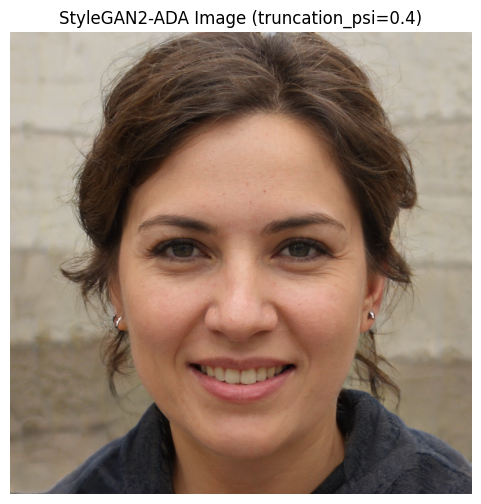

In [11]:
# Generate a new set of images with a lower truncation_psi value for higher average quality
new_truncation_psi = 0.4
new_generated_tensor = generate_images(num_images=16, truncation_psi=new_truncation_psi)

# Display the first image from the new set
new_image_path = 'generated_images/fake_0000.png'
if os.path.exists(new_image_path):
    img = Image.open(new_image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'StyleGAN2-ADA Image (truncation_psi={new_truncation_psi})')
    plt.show()
else:
    print("Generated image not found.")